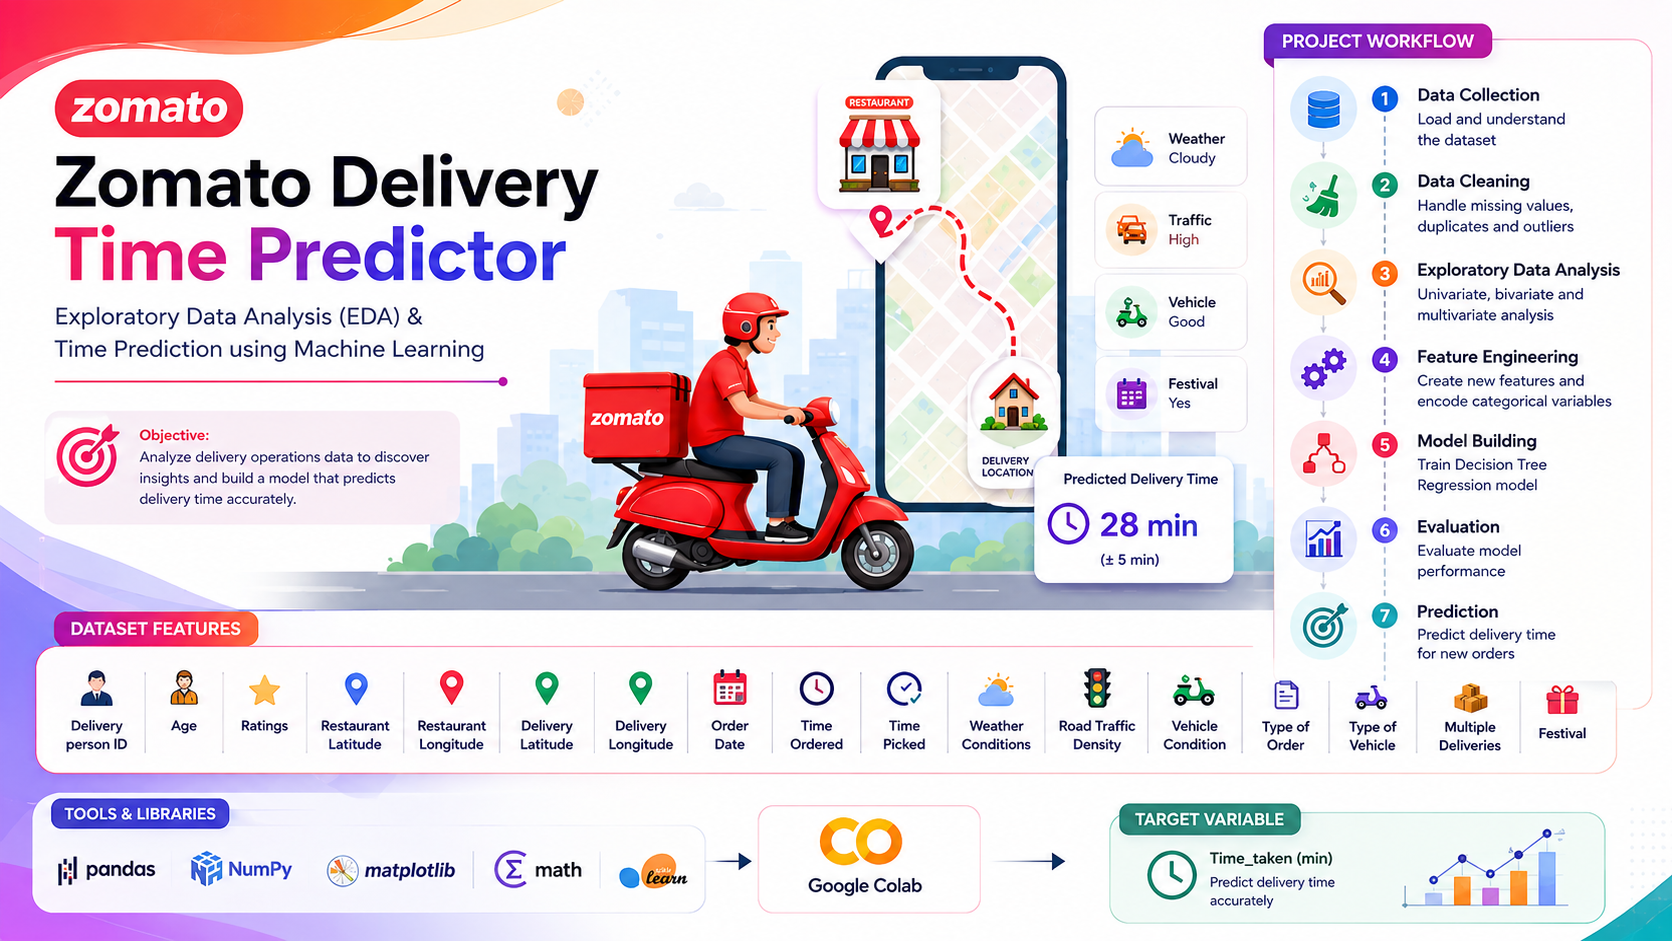

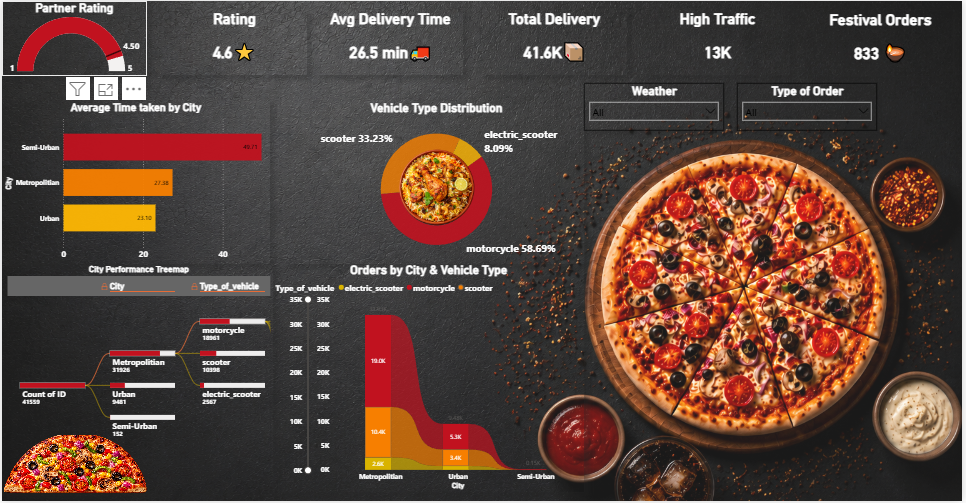

In [ ]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from math import radians, sin, cos, sqrt, atan2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor,plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
print("STEP 1: Loading Dataset...")
df = pd.read_csv("/content/train.csv")
print(f"   Total Rows    : {df.shape[0]}")
print(f"   Total Columns : {df.shape[1]}")


STEP 1: Loading Dataset...
   Total Rows    : 24586
   Total Columns : 20


In [ ]:
print("\n ----columns Names---")
print(df.columns)


 ----columns Names---
Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')


In [ ]:
print("\n STEP 2: Quick Data Overview...")
print(f"\n{"-"*40} First 3 Rows {"-"*40}\n")
print(df.head(3).to_string())
print(f"\n{"-"*20} Data Types {"-"*20}\n")
print(df.dtypes)
print(f"\n{"-"*20} Missing Values{"-"*20}\n")
print(df.isnull().sum())



 STEP 2: Quick Data Overview...

---------------------------------------- First 3 Rows ----------------------------------------

        ID Delivery_person_ID Delivery_person_Age Delivery_person_Ratings  Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  Delivery_location_longitude  Order_Date Time_Orderd Time_Order_picked      Weatherconditions Road_traffic_density  Vehicle_condition Type_of_order Type_of_vehicle multiple_deliveries Festival            City Time_taken(min)
0  0x4607     INDORES13DEL02                   37                     4.9            22.745049             75.892471                   22.765049                    75.912471  19-03-2022    11:30:00          11:45:00       conditions Sunny                High                   2        Snack      motorcycle                    0      No           Urban         (min) 24
1  0xb379     BANGRES18DEL02                   34                     4.5            12.913041             77.683237              

In [ ]:
df['Time_taken(min)'] = df['Time_taken(min)'].str.replace('(min) ', '', regex=False).str.strip()
df['Time_taken(min)'] = pd.to_numeric(df['Time_taken(min)'], errors='coerce')


In [ ]:
#Strip extra whitespace from Numerical columns
df['Delivery_person_Age'] = pd.to_numeric(df['Delivery_person_Age'].astype(str).str.strip(), errors='coerce')
df['Delivery_person_Ratings'] = pd.to_numeric(df['Delivery_person_Ratings'].astype(str).str.strip(), errors='coerce')
df['multiple_deliveries'] = pd.to_numeric(df['multiple_deliveries'].astype(str).str.strip(), errors='coerce')


In [ ]:
#Strip extra whitespace from string columns
str_cols = ['Weatherconditions', 'Road_traffic_density', 'City',
            'Type_of_vehicle', 'Type_of_order', 'Festival']
for col in str_cols:
    df[col] = df[col].astype(str).str.strip()

In [ ]:
df['Weatherconditions'] = df['Weatherconditions'].str.replace('conditions ', '', regex=False).str.strip()

In [ ]:
df.replace('NaN', np.nan, inplace=True)

In [ ]:
df.dropna(subset=['Time_taken(min)', 'Delivery_person_Age',
                  'Delivery_person_Ratings', 'Road_traffic_density',
                  'City', 'Festival', 'multiple_deliveries'], inplace=True)

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

df['distance_km'] = df.apply(
    lambda x: haversine(
        x['Restaurant_latitude'],  x['Restaurant_longitude'],x['Delivery_location_latitude'], x['Delivery_location_longitude']
    ), axis=1)

In [ ]:
df['Time_Orderd'] = df['Time_Orderd'].astype(str).str.strip()
df['order_hour'] = pd.to_datetime(
    df['Time_Orderd'], format='%H:%M:%S', errors='coerce').dt.hour
df['order_hour'].fillna(df['order_hour'].median(), inplace=True)
df['order_hour'] = df['order_hour'].astype(int)

/tmp/ipykernel_1980/3392288089.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['order_hour'].fillna(df['order_hour'].median(), inplace=True)


In [ ]:
df['is_peak_hour'] = df['order_hour'].apply(
    lambda x: 1 if x in [12, 13, 19, 20, 21] else 0)

In [ ]:
def time_diff_minutes(picked, ordered):
    try:
        t1 = pd.to_datetime(str(ordered).strip(), format='%H:%M:%S')
        t2 = pd.to_datetime(str(picked).strip(), format='%H:%M:%S')
        diff = (t2 - t1).seconds / 60
        return diff if diff >= 0 else np.nan
    except:
        return np.nan

df['pickup_time_min'] = df.apply(
    lambda x: time_diff_minutes(x['Time_Order_picked'], x['Time_Orderd']), axis=1)
df['pickup_time_min'].fillna(df['pickup_time_min'].median(), inplace=True)

/tmp/ipykernel_1980/3447052386.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['pickup_time_min'].fillna(df['pickup_time_min'].median(), inplace=True)


In [ ]:
le = LabelEncoder()
cat_cols = ['Weatherconditions', 'Road_traffic_density', 'City',
            'Type_of_vehicle', 'Type_of_order', 'Festival']

encoding_map = {}
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    encoding_map[col] = dict(zip(le.classes_, le.transform(le.classes_)))


/tmp/ipykernel_1980/3549042241.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend()


Text(0, 0.5, 'Avg Delivery Time (min)')

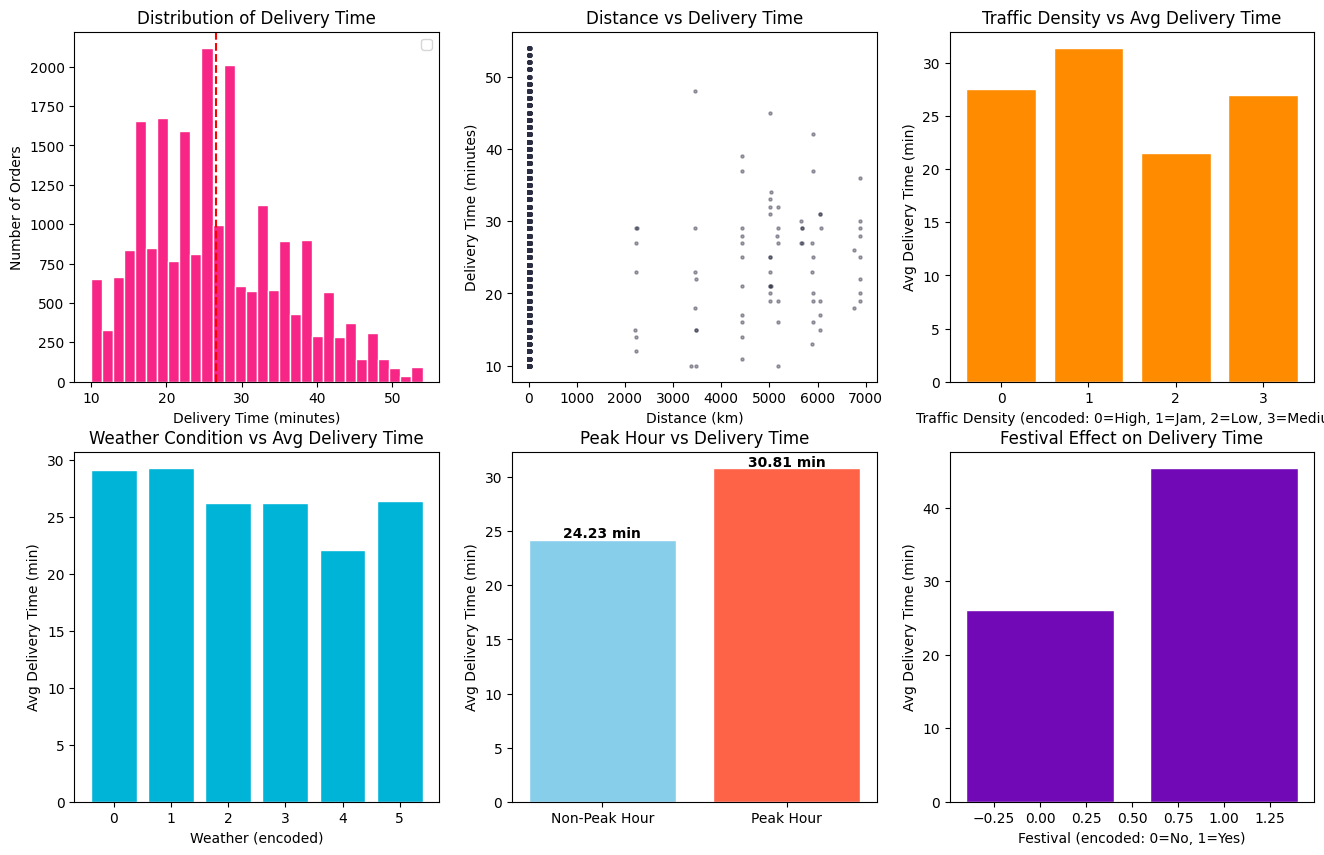

In [ ]:
VIBRANT_BLUE    = '#00b4d8'  # Bright Cyan / Electric Blue
VIBRANT_PURPLE  = '#7209b7'  # Deep Electric Violet
VIBRANT_PINK    = '#f72585'  # Neon Magenta / Pink
VIBRANT_ORANGE  = '#ff9f1c'  # Sunset Orange / Tangerine
NEUTRAL_DARK    = '#2b2d42'  # Sleek dark gray for text/lines to match high contrast
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
# Plot 1: Delivery Time Distribution
axes[0, 0].hist(df['Time_taken(min)'], bins=30, color=VIBRANT_PINK, edgecolor='white')
axes[0, 0].set_title('Distribution of Delivery Time')
axes[0, 0].set_xlabel('Delivery Time (minutes)')
axes[0, 0].set_ylabel('Number of Orders')
axes[0, 0].axvline(df['Time_taken(min)'].mean(), color='red',linestyle='--')
axes[0, 0].legend()

#Plot 2: Distance vs Delivery Time
axes[0, 1].scatter(df['distance_km'], df['Time_taken(min)'],alpha=0.4, color=NEUTRAL_DARK, s=5)
axes[0, 1].set_title('Distance vs Delivery Time')
axes[0, 1].set_xlabel('Distance (km)')
axes[0, 1].set_ylabel('Delivery Time (minutes)')

# Plot 3: Traffic Density vs Avg Delivery Time
traffic_avg = df.groupby('Road_traffic_density')['Time_taken(min)'].mean()
axes[0, 2].bar(range(len(traffic_avg)), traffic_avg.values,color='darkorange', edgecolor='white')
axes[0, 2].set_title('Traffic Density vs Avg Delivery Time')
axes[0, 2].set_xlabel('Traffic Density (encoded: 0=High, 1=Jam, 2=Low, 3=Medium)')
axes[0, 2].set_ylabel('Avg Delivery Time (min)')

# Plot 4: Weather vs Avg Delivery Time
weather_avg = df.groupby('Weatherconditions')['Time_taken(min)'].mean()
axes[1, 0].bar(range(len(weather_avg)), weather_avg.values,color=VIBRANT_BLUE, edgecolor='white')
axes[1, 0].set_title('Weather Condition vs Avg Delivery Time')
axes[1, 0].set_xlabel('Weather (encoded)')
axes[1, 0].set_ylabel('Avg Delivery Time (min)')

# Plot 5: Peak Hour Effect
peak_avg = df.groupby('is_peak_hour')['Time_taken(min)'].mean()
axes[1, 1].bar(['Non-Peak Hour', 'Peak Hour'], peak_avg.values,color=['skyblue', 'tomato'], edgecolor='white')
axes[1, 1].set_title('Peak Hour vs Delivery Time')
axes[1, 1].set_ylabel('Avg Delivery Time (min)')
for i, v in enumerate(peak_avg.values):
    axes[1, 1].text(i, v + 0.2, f'{v:.2f} min', ha='center', fontweight='bold')

# Plot 6: Festival Effect
festival_avg = df.groupby('Festival')['Time_taken(min)'].mean()
axes[1, 2].bar(range(len(festival_avg)), festival_avg.values,color=VIBRANT_PURPLE, edgecolor='white')
axes[1, 2].set_title('Festival Effect on Delivery Time')
axes[1, 2].set_xlabel('Festival (encoded: 0=No, 1=Yes)')
axes[1, 2].set_ylabel('Avg Delivery Time (min)')



<Axes: >

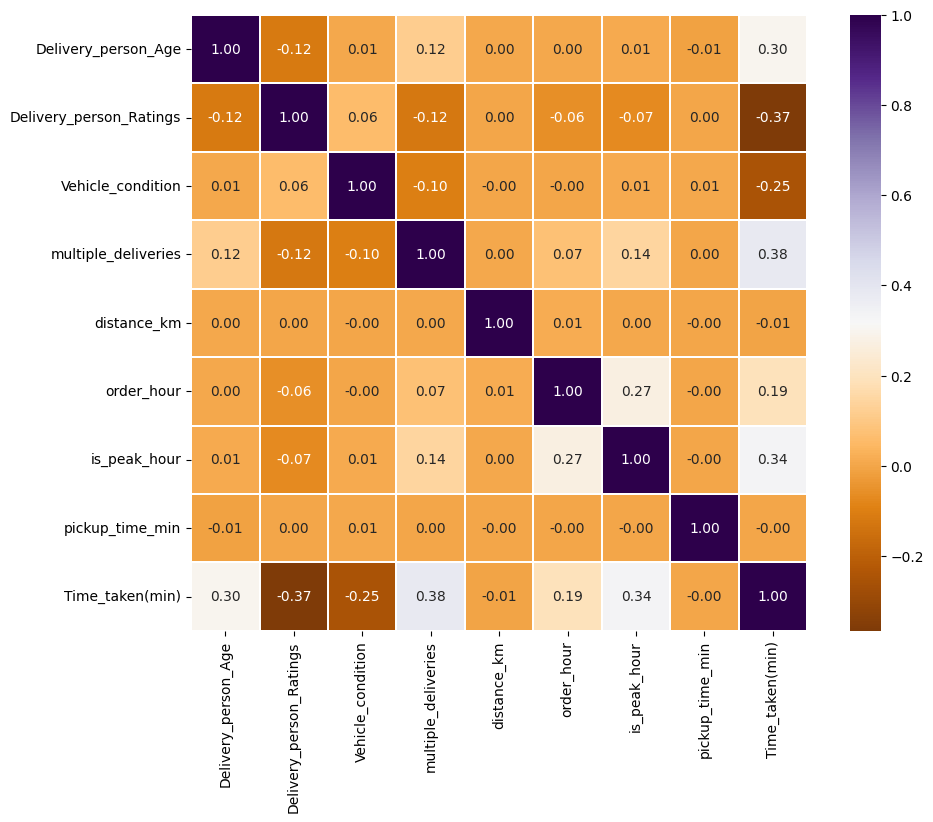

In [ ]:
num_cols = ['Delivery_person_Age', 'Delivery_person_Ratings',
            'Vehicle_condition', 'multiple_deliveries',
            'distance_km', 'order_hour', 'is_peak_hour',
            'pickup_time_min', 'Time_taken(min)']

plt.figure(figsize=(11, 8))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='PuOr',
            linewidths=0.10, square=True)

In [ ]:
features = [
    'Delivery_person_Age',
    'Delivery_person_Ratings',
    'Vehicle_condition',
    'multiple_deliveries',
    'Weatherconditions',
    'Road_traffic_density',
    'Type_of_order',
    'Type_of_vehicle',
    'Festival',
    'City',
    'distance_km',
    'order_hour',
    'is_peak_hour',
    'pickup_time_min' ]

X = df[features]
y = df['Time_taken(min)']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
models = DecisionTreeRegressor(random_state=42, max_depth=10)

In [ ]:
models.fit(X_train, y_train)
pred = models.predict(X_test)

mae  = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2   = r2_score(y_test, pred)
print('-'*60)
print("      DecisionTreeRegressor")
print(f"      MAE      : {mae:.2f} minutes (avg prediction error)")
print(f"      RMSE     : {rmse:.2f}")
print(f"      R² Score : {r2:.4f} ({r2*100:.1f}% accuracy)")


------------------------------------------------------------
      DecisionTreeRegressor
      MAE      : 3.16 minutes (avg prediction error)
      RMSE     : 3.97
      R² Score : 0.8160 (81.6% accuracy)


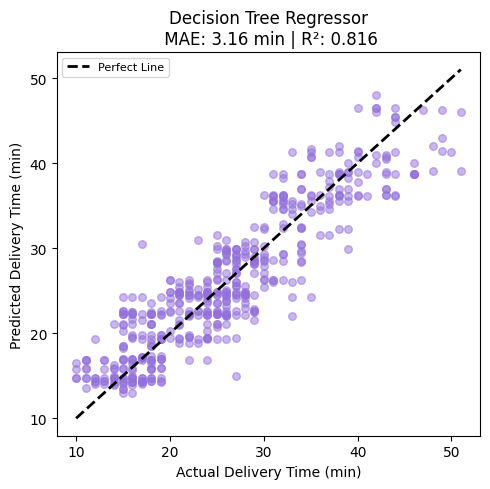

In [ ]:


colors_list = 'mediumpurple'
actual    = y_test.values[:500]
predicted = pred[:500]
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(actual, predicted, alpha=0.50, color=colors_list, s=30)
ax.plot([actual.min(), actual.max()],
                   [actual.min(), actual.max()],
                   'k--', lw=2, label='Perfect Line')
ax.set_title(f"Decision Tree Regressor\n MAE: {mae:.2f} min | R²: {r2:.3f}")
ax.set_xlabel('Actual Delivery Time (min)')
ax.set_ylabel('Predicted Delivery Time (min)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

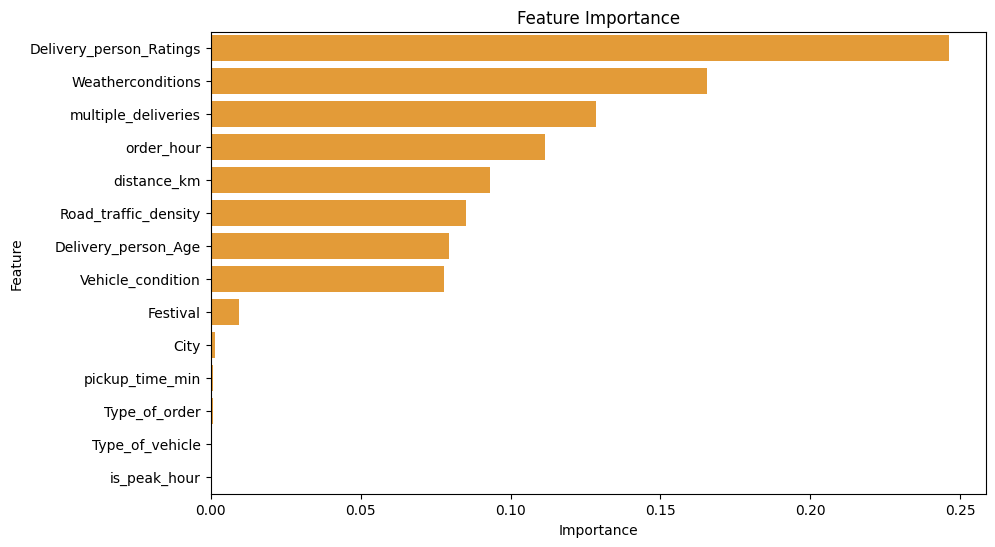

In [ ]:
importance = models.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp, x='Importance', y='Feature',color=VIBRANT_ORANGE)
plt.title('Feature Importance')
plt.show()

# Conclusion

This project focused on predicting food delivery time using machine learning techniques and delivery operations data from Zomato. The dataset included delivery partner information, restaurant and customer locations, weather conditions, traffic density, vehicle details, festival impact, and order-related attributes.

During the analysis, extensive data cleaning and feature engineering were performed to improve data quality and extract meaningful insights. Exploratory Data Analysis (EDA) helped identify important patterns and relationships between delivery time and various operational factors.

A Decision Tree Regression model was developed to estimate delivery time accurately. The model learned delivery patterns from historical data and demonstrated its ability to predict delivery duration based on multiple real-world factors.

The analysis revealed that factors such as distance between restaurant and customer, road traffic density, weather conditions, multiple deliveries, and festival periods have a significant impact on delivery time. These insights can help delivery platforms optimize operations, improve customer satisfaction, and enhance delivery efficiency.

Overall, this project demonstrates the complete machine learning workflow, including data preprocessing, feature engineering, exploratory data analysis, model development, and performance evaluation. It highlights how data-driven approaches can be used to solve real-world logistics and delivery optimization problems.


In [ ]:
df.to_excel('delivery.xlsx', index=False)

In [ ]:
df.shape

(22393, 24)